## (0) Settings and Functions

In [6]:
%load_ext autotime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import  train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

import warnings
from sklearn.exceptions import UndefinedMetricWarning

from scipy.sparse import hstack

import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 1.58 ms (started: 2026-02-19 18:59:24 -03:00)


In [7]:
df = pd.read_csv("../../data/feat/go_emotions_with_features.csv")

print(df.shape)
df.head(3)

(54234, 56)


,UNCLEAN_TEXT_PT,BASE_TEXT_PT,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,punctuation_per_word,exclamation_per_word,question_per_word,mean_verbs_per_word,mean_auxiliaries_per_word,mean_auxiliaries_per_sentence,flesch_portuguese,uppercase_percentage,mean_unique_word_length,mean_char_repetition_per_word
0,Tão rápido quanto [NOME] me carregará. Seriame...,tao rapido quanto nome carregara seriamente up...,0,0,0,0,1,0,0,0,...,0.142857,0.0,0.0,0.095238,0.047619,0.5,77.937143,0.073684,4.388889,0.0
1,Você estragou isso. Eles tocaram você como um ...,voce estragou isso eles tocaram voce como violino,0,0,0,0,0,0,0,0,...,0.222222,0.0,0.0,0.222222,0.000000,0.0,61.320000,0.045455,4.833333,0.0
2,TL;DR Não há mais Super Bowls para [NAME]. Pre...,nao mais super bowls para name prepare-se para...,0,0,0,0,0,0,0,0,...,0.333333,0.0,0.0,0.125000,0.062500,0.5,72.640000,0.134831,4.666667,0.0


time: 746 ms (started: 2026-02-19 18:59:26 -03:00)


In [ ]:
numerical_features = [
    'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 
    'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
    'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 
    'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word'
]

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

def evaluate_on_test_multilabel_smote_per_label(base_model, X_train, y_train, X_test, y_test, model_name="model"):
    models = {}
    y_pred_all = []
    y_score_all = []

    for label_idx, label_name in enumerate(emotion_cols):
        print(f" → Label: {label_name}")

        y_train_label = y_train[:, label_idx]

        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[numerical_features])
        X_test_num = scaler.transform(X_test[numerical_features])

        vectorizer = TfidfVectorizer()
        X_train_text_vec = vectorizer.fit_transform(X_train['BASE_TEXT_PT'])
        X_test_text_vec = vectorizer.transform(X_test['BASE_TEXT_PT'])

        X_train_vec = hstack([X_train_text_vec, X_train_num])
        X_test_vec = hstack([X_test_text_vec, X_test_num])

        if len(np.unique(y_train_label)) > 1:
            smote = SMOTE(random_state=42)
            X_train_vec, y_train_label = smote.fit_resample(
                X_train_vec, y_train_label
            )

        clf = clone(base_model)
        clf.fit(X_train_vec, y_train_label)

        y_pred = clf.predict(X_test_vec)

        if hasattr(clf, "predict_proba"):
            y_score = clf.predict_proba(X_test_vec)[:, 1]
        else:
            y_score = None

        y_pred_all.append(y_pred)
        y_score_all.append(y_score)

        models[label_name] = {
            "model": clf,
            "vectorizer": vectorizer,
            "scaler": scaler
        }

    y_pred_all = np.array(y_pred_all).T
    y_score_all = np.array(y_score_all).T if y_score_all[0] is not None else None

    metrics_df = pd.DataFrame({
        "Accuracy": [accuracy_score(y_test, y_pred_all)],
        "Precision (Macro)": [precision_score(y_test, y_pred_all, average="macro", zero_division=0)],
        "Recall (Macro)": [recall_score(y_test, y_pred_all, average="macro", zero_division=0)],
        "F1 (Macro)": [f1_score(y_test, y_pred_all, average="macro", zero_division=0)],
        "F1 (Micro)": [f1_score(y_test, y_pred_all, average="micro", zero_division=0)],
        "F1 (Weighted)": [f1_score(y_test, y_pred_all, average="weighted", zero_division=0)]
    })

    print("\n===== MÉTRICAS GLOBAIS MULTILABEL =====")
    print(metrics_df.round(4))

    if y_score_all is not None:

        plt.figure(figsize=(10, 8))

        for i, label_name in enumerate(emotion_cols):
            fpr, tpr, _ = roc_curve(y_test[:, i], y_score_all[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{label_name} (AUC={roc_auc:.2f})")

        plt.plot([0, 1], [0, 1])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Curva ROC Multilabel")
        plt.legend()
        plt.show()

        print("\nMacro ROC-AUC:",
              roc_auc_score(y_test, y_score_all, average="macro"))

    model_file = f"../../data/model/GoEmotions_{model_name}.jolib"
    joblib.dump(models, model_file)

    print(f"\nModelos salvos em: {model_file}")
    
    metrics_df.to_csv(f"../../data/out/final/GoEmotions_{model_name}_global_metrics.csv", index=False)

time: 2.59 ms (started: 2026-02-19 18:59:27 -03:00)


In [9]:
df['BASE_TEXT_PT'] = (
    df['BASE_TEXT_PT']
    .fillna("")
    .astype(str)
)

emotion_cols = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

numerical_features = [
    'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 
    'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word',
    'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 
    'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word'
]

cols_input = ['BASE_TEXT_PT'] + numerical_features

X = df[cols_input]
y = df[emotion_cols].values

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    train_size=0.70,
    random_state=42,
)

X_dev, X_test, y_dev, y_test = train_test_split(
    X_aux, y_aux,
    train_size=0.50,
    random_state=42,
)

print(X_train.shape, X_dev.shape, X_test.shape)

(37963, 17) (8135, 17) (8136, 17)
time: 46.4 ms (started: 2026-02-19 18:59:29 -03:00)


 → Label: admiration
 → Label: amusement
 → Label: anger
 → Label: annoyance
 → Label: approval
 → Label: caring
 → Label: confusion
 → Label: curiosity
 → Label: desire
 → Label: disappointment
 → Label: disapproval
 → Label: disgust
 → Label: embarrassment
 → Label: excitement
 → Label: fear
 → Label: gratitude
 → Label: grief
 → Label: joy
 → Label: love
 → Label: nervousness
 → Label: optimism
 → Label: pride
 → Label: realization
 → Label: relief
 → Label: remorse
 → Label: sadness
 → Label: surprise
 → Label: neutral

===== MÉTRICAS GLOBAIS MULTILABEL =====
   Accuracy  Precision (Macro)  Recall (Macro)  F1 (Macro)  F1 (Micro)  \
0    0.1874             0.3096          0.5527      0.3881      0.4569   

   F1 (Weighted)  
0         0.4934  


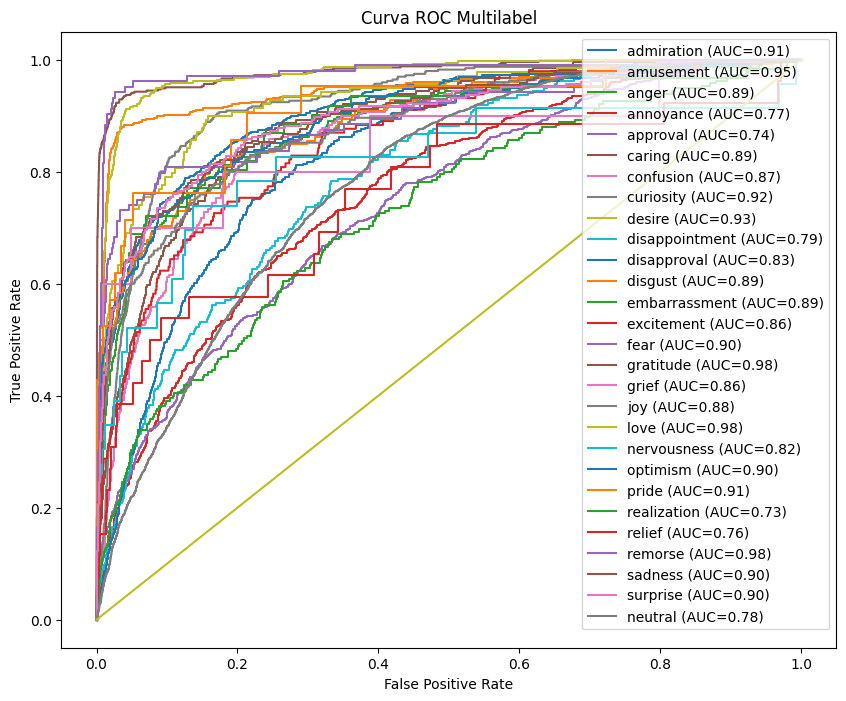


Macro ROC-AUC: 0.8707830843111959

Modelos salvos em: ../../data/model/GoEmotions_LogisticRegression_TFIDF.jolib
time: 1min 12s (started: 2026-02-19 18:59:31 -03:00)


In [10]:
model = LogisticRegression(max_iter=1000, random_state=42)

evaluate_on_test_multilabel_smote_per_label(model, X_train, y_train, X_test, y_test, model_name="LogisticRegression_TFIDF")